In [31]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as sci_plt
import yfinance as yf

from pprint import pprint

pd.set_option('display.max_colwidth', None)
pd.set_option('expand_frame_repr', False)

In [32]:
# Creating my own new Data with recent price data for the stocks I want to use in my portfolio optimization

import yfinance as yf

symbols = ['AAPL', 'MSFT', 'XYZ', 'AMZN']   # Square's ticker is now XYZ (was SQ)

raw = yf.download(
    symbols,
    start='2025-09-19',
    end='2026-09-20',      # end date is exclusive, so this includes 19 Sept
    auto_adjust=True,
)

# Keep only closing prices, one column per stock
price_data_frame = raw['Close'][symbols].dropna()

# Save to CSV (../data because the notebook sits in samples/)
price_data_frame.to_csv('stock_data_new.csv')

print(price_data_frame.head())
print(price_data_frame.shape)
print(price_data_frame.columns.tolist())
print(price_data_frame.shape)

[*********************100%***********************]  4 of 4 completed

Ticker            AAPL        MSFT        XYZ        AMZN
Date                                                     
2025-09-19  244.596451  513.703369  77.029999  231.479996
2025-09-22  255.137512  510.251770  77.410004  227.630005
2025-09-23  253.493591  505.074463  76.540001  220.710007
2025-09-24  251.381409  505.986908  76.489998  220.210007
2025-09-25  255.924606  502.892365  73.680000  218.149994
(251, 4)
['AAPL', 'MSFT', 'XYZ', 'AMZN']
(251, 4)


In [33]:
print(price_data_frame.head())
print(price_data_frame.dtypes)

Ticker            AAPL        MSFT        XYZ        AMZN
Date                                                     
2025-09-19  244.596451  513.703369  77.029999  231.479996
2025-09-22  255.137512  510.251770  77.410004  227.630005
2025-09-23  253.493591  505.074463  76.540001  220.710007
2025-09-24  251.381409  505.986908  76.489998  220.210007
2025-09-25  255.924606  502.892365  73.680000  218.149994
Ticker
AAPL    float64
MSFT    float64
XYZ     float64
AMZN    float64
dtype: object


In [34]:
# Calculate the Log Returns.
log_returns = np.log(1 + price_data_frame.pct_change()) 

# Generate some random weights for the portfolio.
random_weights = np.array(np.random.random(number_of_symbols))

# Rebalance the weights to sum to 1.
rebalanced_weights = random_weights / np.sum(random_weights)
display(rebalanced_weights)

# Calculate the expected return, Annualized.
exp_return = np.sum(log_returns.mean() * rebalanced_weights) * 252                  #252 trading days in a year

# Calulate the expected volatility, Annualized.
exp_vol = np.sqrt(
    np.dot(
        rebalanced_weights.T, 
        np.dot(
            log_returns.cov() * 252, 
            rebalanced_weights
        )
    )
)

# Calculate the Sharpe Ratio.
sharpe_ratio = (exp_return - 0.01) / exp_vol

# Put the weights into a data frame to see them better.
weights_df = pd.DataFrame(data={
'random_weights': random_weights,
'rebalanced_weights': rebalanced_weights
})
print('')
print('='*80)
print('PORTFOLIO WEIGHTS:')
print('-'*80)
print(weights_df)
print('-'*80)

# Do the same with the other metrics.
metrics_df = pd.DataFrame(data={
    'Expected Portfolio Returns': exp_return,
    'Expected Portfolio Volatility': exp_vol,
    'Portfolio Sharpe Ratio': sharpe_ratio
}, index=[0])

print('')
print('='*80)
print('PORTFOLIO METRICS:')
print('-'*80)
print(metrics_df)
print('-'*80)

array([0.1693205 , 0.23486211, 0.1530816 , 0.44273579])


PORTFOLIO WEIGHTS:
--------------------------------------------------------------------------------
   random_weights  rebalanced_weights
0        0.259100            0.169320
1        0.359394            0.234862
2        0.234251            0.153082
3        0.677490            0.442736
--------------------------------------------------------------------------------

PORTFOLIO METRICS:
--------------------------------------------------------------------------------
   Expected Portfolio Returns  Expected Portfolio Volatility  Portfolio Sharpe Ratio
0                    0.084304                        0.24248                0.306434
--------------------------------------------------------------------------------


In [35]:
# THE MONTE CARLO SIMULATION

# Define the number of simulations we want to run.
num_portfolios = 4000

# Prep the weight array to hold the weights for each simulation.
all_weights = np.zeros((num_portfolios, number_of_symbols))

# Prep the array to hold the expected returns for each simulation.
ret_arr = np.zeros(num_portfolios)

# Prep the array to hold the expected volatility for each simulation.
vol_arr = np.zeros(num_portfolios)

# Prep the array to hold the Sharpe Ratio for each simulation.
sharpe_arr = np.zeros(num_portfolios)

#Start the Monte Carlo Simulation.
for ind in range(num_portfolios):

    # Generate random weights for the portfolio.
    weights = np.array(np.random.random(number_of_symbols))

    # Rebalance the weights to sum to 1.
    weights = weights / np.sum(weights)

    # Save the weights.
    all_weights[ind, :] = weights

    # Calculate the expected return, Annualized.
    ret_arr[ind] = np.sum(log_returns.mean() * weights) * 252                  #252 trading days in a year

    # Calulate the expected volatility, Annualized.
    vol_arr[ind] = np.sqrt(
        np.dot(
            weights.T, 
            np.dot(
                log_returns.cov() * 252, 
                weights
            )
        )
    )

    # Calculate the Sharpe Ratio.
    sharpe_arr[ind] = (ret_arr[ind] - 0.01) / vol_arr[ind]

# Combine the arrays into a data frame for easier viewing.
simulations_data = [ret_arr, vol_arr, sharpe_arr, all_weights]

# Create a data frame to hold the simulation results.
simulations_df = pd.DataFrame(data=simulations_data).T

# Give the columns the Proper Names.
simulations_df.columns = [
    'Returns',
    'Volatility',
    'Sharpe Ratio',
    'Portfolio Weights'
]

# Make sure the data types are correct, we don't want our floats to be strings.
simulations_df = simulations_df.infer_objects()

# Print out the results.
print('')
print('='*80)
print('SIMULATIONS RESULT:')
print('-'*80)
print(simulations_df.head())
print('-'*80)


SIMULATIONS RESULT:
--------------------------------------------------------------------------------
    Returns  Volatility  Sharpe Ratio                                                                      Portfolio Weights
0  0.046965    0.254446      0.145277     [0.09202525732129616, 0.3465837492631285, 0.20131999011556254, 0.3600710033000128]
1  0.075733    0.267476      0.245751   [0.19123332917087182, 0.16048129381251897, 0.38191820642822705, 0.26636717058838216]
2  0.040878    0.253503      0.121806  [0.10501980931970586, 0.5702855879771288, 0.00045949029340722756, 0.3242351124097581]
3  0.075629    0.250985      0.261486      [0.2010187078664617, 0.23260545000137495, 0.3114589321903222, 0.2549169099418411]
4  0.084788    0.227335      0.328978     [0.2166366065547821, 0.34716651233792817, 0.1085601334021902, 0.32763674770509965]
--------------------------------------------------------------------------------


In [36]:
# Grab the index of the maximum Sharpe Ratio.
max_sharpe_ratio = simulations_df.loc[simulations_df['Sharpe Ratio'].idxmax()]

# Return the minimum volatility portfolio.
min_volatility = simulations_df.loc[simulations_df['Volatility'].idxmin()]

print('')
print('='*80)
print('MAX SHARPE RATIO:')
print('-'*80)
print(max_sharpe_ratio)
print('-'*80)

print('')
print('='*80)
print('MIN VOLATILITY:')
print('-'*80)
print(min_volatility)
print('-'*80)


MAX SHARPE RATIO:
--------------------------------------------------------------------------------
Returns                                                                                           0.27338
Volatility                                                                                       0.220307
Sharpe Ratio                                                                                     1.195517
Portfolio Weights    [0.8411340289515528, 0.07540927228122758, 0.008336819925775703, 0.07511987884144387]
Name: 2233, dtype: object
--------------------------------------------------------------------------------

MIN VOLATILITY:
--------------------------------------------------------------------------------
Returns                                                                                          0.196426
Volatility                                                                                       0.196854
Sharpe Ratio                                               

/var/folders/pl/65wl7kpj6szcn35g4gtswflr0000gn/T/ipykernel_67869/1385387819.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  max_sharpe_ratio[1],
/var/folders/pl/65wl7kpj6szcn35g4gtswflr0000gn/T/ipykernel_67869/1385387819.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  max_sharpe_ratio[0],
/var/folders/pl/65wl7kpj6szcn35g4gtswflr0000gn/T/ipykernel_67869/1385387819.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  min_vol

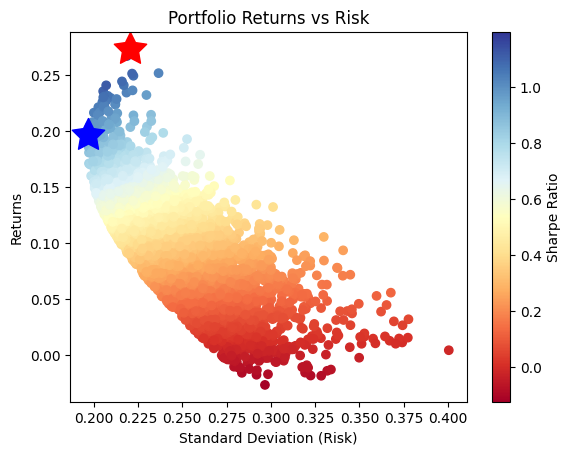

In [37]:
# Plotting the results of the Monte Carlo Simulation.

%matplotlib inline

# Plotting on a scatter plot.

plt.scatter(
    y=simulations_df['Returns'],
    x=simulations_df['Volatility'],
    c=simulations_df['Sharpe Ratio'],
    cmap = 'RdYlBu'
)

# Give the plot title and axis labels.
plt.title('Portfolio Returns vs Risk')
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Standard Deviation (Risk)')
plt.ylabel('Returns')

#Plot the Maximum Sharpe Ratio point using a Red Star.
plt.scatter(
    max_sharpe_ratio[1],
    max_sharpe_ratio[0],
    marker=(5, 1, 0),
    color='r',
    s=600,
)

#Plot the Minimum Volatility point using a Blue Star.
plt.scatter(
    min_volatility[1],
    min_volatility[0],
    marker=(5, 1, 0),
    color='b',
    s=600,
)

# Finally, show the plot.
plt.show()

In [38]:
# Optimization of the Portfolio using Scipy's minimize function.

def get_metrics(weights: list) -> np.array:

    # Convert the rates to a numpy array.
    weights = np.array(weights)

    # Calculate the expected return, Annualized.
    exp_return = np.sum(log_returns.mean() * weights) * 252

    # Calulate the expected volatility, Annualized.
    exp_vol = np.sqrt(
        np.dot(
            weights.T, 
            np.dot(
                log_returns.cov() * 252, 
                weights
            )
        )
    )

    # Calculate the Sharpe Ratio.
    sharpe_ratio = (exp_return - 0.01) / exp_vol

    return np.array([exp_return, exp_vol, sharpe_ratio])

def grab_negative_sharpe(weights: list) -> np.array:

    return -get_metrics(weights)[2]

def grab_volatility(weights: list) -> np.array:

    return get_metrics(weights)[1]

def check_sum(weights: list) -> float:

    return np.sum(weights) - 1

In [39]:
# Scipy Optimization for Sharpe Ratio Maximization

# Define the bounds in our optimization process. (Makes sure no asset is more than 100% of the portfolio)

bounds = tuple((0, 1) for symbol in range(number_of_symbols))

# Define the constraints in our optimization process. (Makes sure the weights do not exceed 1)
constraints = ({'type': 'eq', 'fun': check_sum})

# Define the initial guesses.
init_guesses = number_of_symbols * [1 / number_of_symbols]

# Perform the optimization to maximize the Sharpe Ratio.
optimized_sharpe = sci_plt.minimize(
    grab_negative_sharpe,      #what we want to minimize
    init_guesses,              #initial guesses
    method='SLSQP',            #optimization method (Sequential Least Squares Programming)
    bounds=bounds,             #apply bounds
    constraints=constraints    #apply constraints
)

# Print the results.
print('')
print('='*80)
print('OPTIMIZED SHARPE RATIO:')
print('-'*80)
print(optimized_sharpe)
print('-'*80)


OPTIMIZED SHARPE RATIO:
--------------------------------------------------------------------------------
 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -1.2502991465038067
       x: [ 9.268e-01  0.000e+00  3.148e-16  7.321e-02]
     nit: 4
     jac: [-4.267e-02  4.460e-01  6.682e-01 -4.124e-02]
    nfev: 20
    njev: 4
--------------------------------------------------------------------------------


In [40]:
#Grab the Final Results

optimized_metrics = get_metrics(weights=optimized_sharpe.x)

# Print the Optimized Weights.
print('')
print('='*80)
print('OPTIMIZED WEIGHTS:')
print('-'*80)
print(optimized_sharpe.x)
print('-'*80)


# Print the Optimized Metrics.
print('')
print('='*80)
print('OPTIMIZED METRICS:')
print('-'*80)
print(optimized_metrics)
print('-'*80)


OPTIMIZED WEIGHTS:
--------------------------------------------------------------------------------
[9.26788865e-01 0.00000000e+00 3.14817217e-16 7.32111350e-02]
--------------------------------------------------------------------------------

OPTIMIZED METRICS:
--------------------------------------------------------------------------------
[0.30373931 0.23493522 1.25029915]
--------------------------------------------------------------------------------


In [41]:
# Scipy Optimization for Volatility Minimization

# Define the bounds in our optimization process. (Makes sure no asset is more than 100% of the portfolio)

bounds = tuple((0, 1) for symbol in range(number_of_symbols))

# Define the constraints in our optimization process. (Makes sure the weights do not exceed 1)
constraints = ({'type': 'eq', 'fun': check_sum})

# Define the initial guesses.
init_guesses = number_of_symbols * [1 / number_of_symbols]

# Perform the optimization to maximize the Sharpe Ratio.
optimized_volatility = sci_plt.minimize(
    grab_volatility,           #what we want to minimize
    init_guesses,              #initial guesses
    method='SLSQP',            #optimization method (Sequential Least Squares Programming)
    bounds=bounds,             #apply bounds
    constraints=constraints    #apply constraints
)

# Print the results.
print('')
print('='*80)
print('OPTIMIZED VOLATILITY:')
print('-'*80)
print(optimized_volatility)
print('-'*80)


OPTIMIZED VOLATILITY:
--------------------------------------------------------------------------------
 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.19646216614884332
       x: [ 5.548e-01  2.303e-01  7.694e-03  2.072e-01]
     nit: 7
     jac: [ 1.965e-01  1.966e-01  1.969e-01  1.962e-01]
    nfev: 35
    njev: 7
--------------------------------------------------------------------------------


In [42]:
# Grab the metrics.
optimized_metrics = get_metrics(weights=optimized_volatility.x)

# Print the Optimized Weights.
print('')
print('='*80)
print('OPTIMIZED WEIGHTS:')
print('-'*80)
print(optimized_volatility.x)
print('-'*80)


# Print the Optimized Metrics.
print('')
print('='*80)
print('OPTIMIZED METRICS:')
print('-'*80)
print(optimized_metrics)
print('-'*80)


OPTIMIZED WEIGHTS:
--------------------------------------------------------------------------------
[0.55476572 0.23029191 0.00769419 0.20724817]
--------------------------------------------------------------------------------

OPTIMIZED METRICS:
--------------------------------------------------------------------------------
[0.18766256 0.19646217 0.90430927]
--------------------------------------------------------------------------------


In [43]:
def optimize_weights(returns_df, rf=0.01):
    n = returns_df.shape[1]
    mean = returns_df.mean() * 252
    cov = returns_df.cov() * 252

    def neg_sharpe(w):
        ret = np.sum(mean * w)
        vol = np.sqrt(w @ cov.values @ w)
        return -(ret - rf) / vol

    res = sci_plt.minimize(
        neg_sharpe,
        n * [1 / n],
        method='SLSQP',
        bounds=tuple((0, 1) for _ in range(n)),
        constraints=({'type': 'eq', 'fun': lambda w: np.sum(w) - 1}),
    )
    return res.x

price_data_frame.index = pd.to_datetime(price_data_frame.index)
all_log_returns = np.log(1 + price_data_frame.pct_change()).dropna()
months = all_log_returns.index.to_period('M')
unique_months = months.unique()

results = []
for i in range(4, len(unique_months)):          # need at least 4 months to train
    train = all_log_returns[months < unique_months[i]]
    test = all_log_returns[months == unique_months[i]]

    w = optimize_weights(train)
    test_daily = test.values @ w                 # daily portfolio log return

    results.append({
        'test_month': str(unique_months[i]),
        'weights': np.round(w, 2),
        'test_return': test_daily.sum(),         # actual return over that month
    })

results_df = pd.DataFrame(results)
print(results_df)
print('Total out-of-sample log return:', results_df['test_return'].sum())

  test_month                 weights  test_return
0    2026-01    [1.0, 0.0, 0.0, 0.0]    -0.046608
1    2026-02  [0.92, 0.0, 0.0, 0.08]     0.006200
2    2026-03    [1.0, 0.0, 0.0, 0.0]    -0.040124
3    2026-04    [1.0, 0.0, 0.0, 0.0]     0.066902
4    2026-05  [0.62, 0.0, 0.0, 0.38]     0.094654
5    2026-06  [0.86, 0.0, 0.0, 0.14]    -0.082581
6    2026-07    [1.0, 0.0, 0.0, 0.0]     0.065378
7    2026-08  [0.76, 0.0, 0.0, 0.24]     0.009474
8    2026-09  [0.86, 0.0, 0.0, 0.14]     0.047513
Total out-of-sample log return: 0.12080993392153352


In [44]:
test_months = results_df['test_month'].tolist()
mask = months.astype(str).isin(test_months)
equal_w = np.array([0.25, 0.25, 0.25, 0.25])
eq_daily = all_log_returns[mask].values @ equal_w
print('Equal-weight total log return:', eq_daily.sum())
print('Optimizer total log return:   ', results_df['test_return'].sum())

# Buy-and-hold each single stock over the same period
print(all_log_returns[mask].sum())

Equal-weight total log return: 0.12380934859930362
Optimizer total log return:    0.12080993392153352
Ticker
AAPL    0.214929
MSFT    0.027115
XYZ     0.158640
AMZN    0.094554
dtype: float64
